In [1]:
import pandas as pd
import pyreadstat
from tqdm import tqdm; tqdm.pandas()
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager
import matplotlib.dates as mdates
import statsmodels.formula.api as smf
from pygam import LinearGAM, s
from ast import literal_eval
import krippendorff
import re
from matplotlib.ticker import FuncFormatter
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from collections import Counter
pd.options.mode.chained_assignment = None
from matplotlib.lines import Line2D
import textwrap
from scipy.stats import pearsonr
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import spacy
import random
import krippendorff
from sklearn.preprocessing import MinMaxScaler
import matplotlib.cm as cm
from itertools import chain, combinations
from scipy.stats import linregress
import matplotlib as mpl

## Sentiment per maand berekenen

In [21]:
df2 = pd.read_csv("df4.csv", index_col=0)

In [24]:
# In deze code wordt het gemiddelde sentiment per categorie (negatief, neutraal, positief) berekend.  

def extract_mean_sentiment(scores, category="neutral"):
    sentiments = []
    for score in scores:
        sentiment = score.get(category)  
        sentiments.append(sentiment)  
    return np.mean(sentiments) 

# De functie wordt toegepast om de gemiddelde scores per categorie te berekenen.
df2["mean_negative"] = df2.police_sentences_sentiment.progress_apply(lambda x: extract_mean_sentiment(x, category="negative"))
df2["mean_neutral"] = df2.police_sentences_sentiment.progress_apply(lambda x: extract_mean_sentiment(x, category="neutral"))
df2["mean_positive"] = df2.police_sentences_sentiment.progress_apply(lambda x: extract_mean_sentiment(x, category="positive"))

# Het totale sentiment wordt berekend door de negatieve score van de positieve af te trekken.
df2["mean_sentiment"] = df2["mean_positive"] - df2["mean_negative"]

100%|██████████████████████████████████████████████████████████████████████████| 1304/1304 [00:00<00:00, 217357.72it/s]


In [25]:
# In deze code wordt per zin het sentiment bepaald.  
# Daarna wordt berekend hoe vaak elk sentiment voorkomt en hoe sterk het sentiment is.  

def get_max_sentiments(scores):
    max_sentiments = []
    for s in scores:
        max_sentiment = max(s, key=s.get) 
        max_sentiments.append(max_sentiment)  
    return max_sentiments  

df2["max_sentiment_codes"] = df2.police_sentences_sentiment.progress_apply(lambda x: get_max_sentiments(x))

# Het aandeel van elk sentiment wordt berekend.
df2["prop_negative"] = df2.max_sentiment_codes.progress_apply(lambda x: x.count("negative") / len(x))
df2["prop_neutral"] = df2.max_sentiment_codes.progress_apply(lambda x: x.count("neutral") / len(x))
df2["prop_positive"] = df2.max_sentiment_codes.progress_apply(lambda x: x.count("positive") / len(x))

# Het aandeel niet-neutrale zinnen en het verschil tussen positief en negatief sentiment worden berekend.
df2["non_neutral"] = 1 - df2["prop_neutral"]
df2["diff_sentiment"] = df2["prop_positive"] - df2["prop_negative"]

100%|█████████████████████████████████████████████████████████████████████████| 1304/1304 [00:00<00:00, 1303783.65it/s]


In [33]:
# In deze code worden de datumgegevens verwerkt en maandelijkse gemiddelden berekend.  
# Daarna worden de data gestandaardiseerd per outlet.  

# De datum wordt omgezet naar een datumtijd-formaat en naar maanden gegroepeerd.
df2["date"] = pd.to_datetime(df2["date"], errors='coerce')
df2["month"] = df2['date'].dt.to_period('M')

# De gemiddelde sentimentsscores per maand en outlet worden berekend.
features = ["abs_sentiment", "non_neutral", "diff_sentiment", "prop_negative", "prop_neutral", "prop_positive"]
df_month = df2.groupby(["month", 'outlet_type', 'outlet'])[features].mean().reset_index()
df_month["month_codes"] = pd.Categorical(df_month['month']).codes

# De hoeveelheid aandacht per maand en outlet wordt berekend.
df_attention = df2.groupby(["month", 'outlet_type', 'outlet']).size().reset_index().rename(columns={0: "attention"})
df_attention["month_codes"] = pd.Categorical(df_attention['month']).codes
df_month = df_month.merge(df_attention.drop(columns=['month']), on=["month_codes", 'outlet_type', 'outlet'])

def z_standardize(group):
    return (group - group.mean()) / group.std()
numeric_cols = df_month.select_dtypes(include='number').columns
df_month[[f"z_{col}" for col in numeric_cols]] = df_month.groupby("outlet")[numeric_cols].transform(z_standardize)

## Aantal nieuwsartikelen

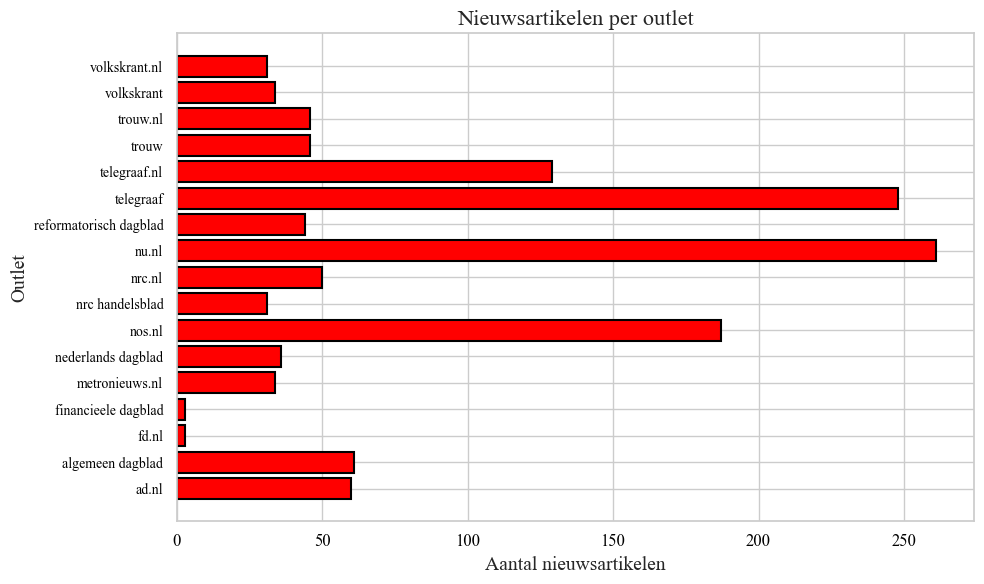

In [193]:
# Deze code maakt een horizontale staafgrafiek die het aantal nieuwsartikelen per outlet toont.  
# Eerst wordt het aantal artikelen per outlet berekend en gesorteerd op naam van de outlet.  
# Daarna wordt de grafiek opgebouwd, met de outlets aan de verticale as en het aantal artikelen aan de horizontale as.  

outlet_size = df2.groupby("outlet").size()
outlet_size_sorted = outlet_size.sort_index(ascending=True, key=lambda x: x.str.lower())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    outlet_size_sorted.index,  # Outlets on the y-axis
    outlet_size_sorted.values,  # Number of articles on the x-axis
    color='red', 
    edgecolor='black', 
    linewidth=1.5)

font_properties = {'fontsize': 14, 'fontname': 'Times New Roman'}

ax.set_title("Nieuwsartikelen per outlet", fontsize=16, fontname="Times New Roman")
ax.set_xlabel("Aantal nieuwsartikelen", **font_properties)  # X-axis is now the count
ax.set_ylabel("Outlet", **font_properties)  # Y-axis is now the outlet

ax.tick_params(axis='x', labelsize=12, labelcolor="black")
ax.tick_params(axis='y', labelsize=10, labelcolor="black")
for tick in ax.get_xticklabels():
    tick.set_fontname("Times New Roman")
for tick in ax.get_yticklabels():
    tick.set_fontname("Times New Roman")

plt.tight_layout()
plt.savefig('figures/Nieuwsartikelen per outlet_horizontal.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [146]:
# Deze code maakt een lijngrafiek van de gegevens, waarbij de gemiddelde waarden per maand worden weergegeven.  
# De data wordt herschikt zodat de maand op de horizontale as staat en de outlet op de verticale as.  
# De grafiek toont de gemiddelde waarde per maand in zwart met een lijn.  

def get_group_visuals(variable=None, data=df_month, title=None, ylabel=None, alpha=.5, zero=True, save_txt=False, ymin=0, ymax=1):
    data_t = data.pivot(index='month', columns='outlet', values=variable)
    data_t['average'] = data_t.sum(axis=1)
    
    plt.rcParams['font.family'] = ['Times New Roman']
    ax = data_t['average'].plot(kind='line', color='black', linestyle='-', linewidth=2,
                                label='gemiddelde', figsize=(10, 6), title=title)
    sns.set(font_scale=1, style="whitegrid")
    plt.xlabel('Maand')
    plt.ylabel(ylabel)
    if zero == True:
        plt.axhline(y=0, color="red")
    font_prop = font_manager.FontProperties(family='Times New Roman')
    plt.grid(True)
    if save_txt:
        variable = variable + save_txt
    plt.ylim(ymin, ymax)
    plt.savefig(f'figures/{title}.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
    plt.show()

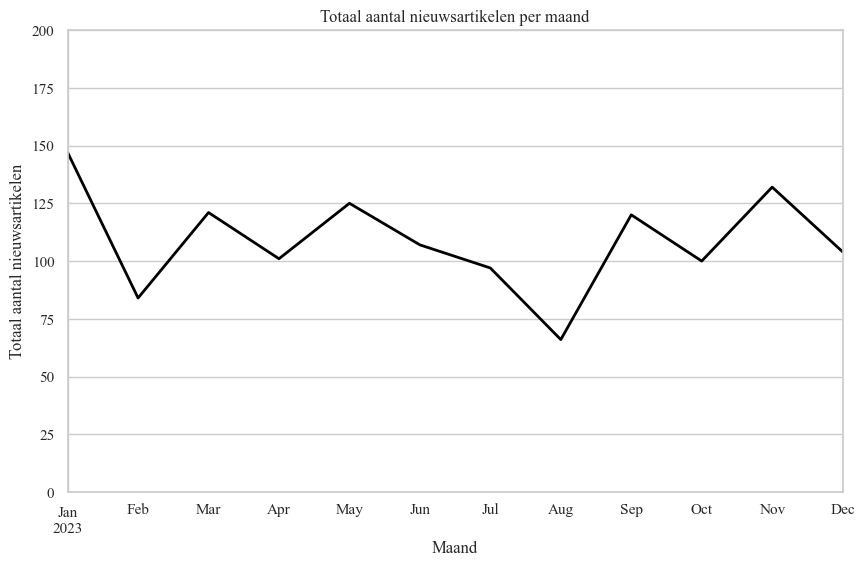

In [165]:
get_group_visuals("attention", ylabel = "Totaal aantal nieuwsartikelen",
                  title="Totaal aantal nieuwsartikelen per maand", data=df_month, zero=False, ymax=200)

## Sentiment

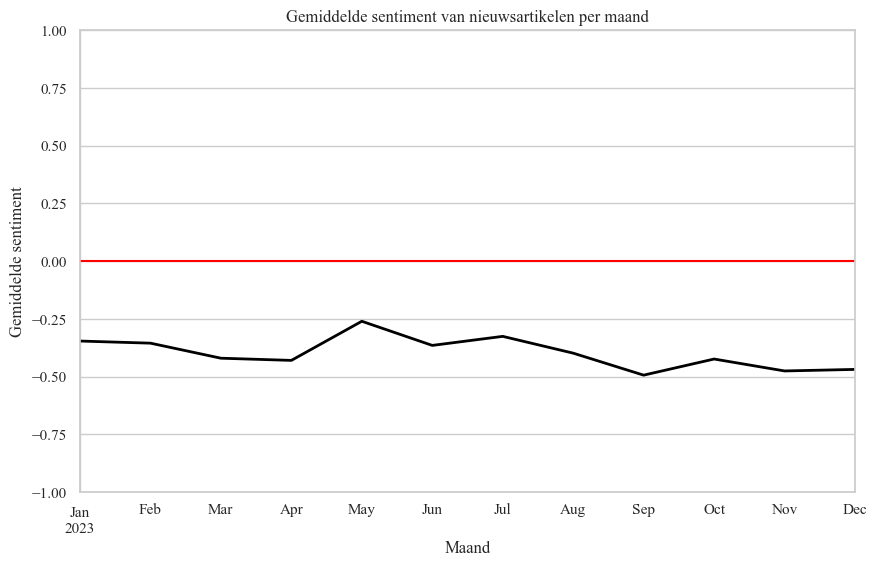

In [110]:
get_group_visuals("diff_sentiment", ylabel = "Gemiddelde sentiment",
                  title="Gemiddelde sentiment van nieuwsartikelen per maand", data=df_month, zero=True, ymin=-1)

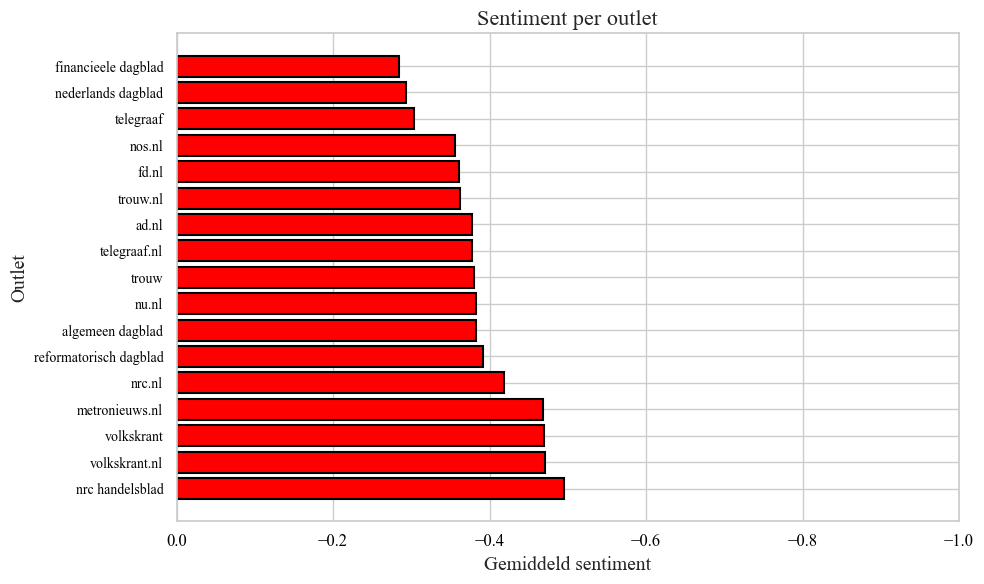

In [195]:
# De code maakt een horizontale staafgrafiek die het gemiddelde sentiment per outlet toont.  
# Het sentiment wordt gegroepeerd per outlet en het gemiddelde sentiment per outlet wordt berekend.  
# De outlets worden gesorteerd van het meest negatieve sentiment naar het minst negatieve (door de waarden oplopend te sorteren).  
# De grafiek toont de gemiddelde sentimenten per outlet, waarbij negatieve waarden naar links gaan.  
# De horizontale as wordt van 0 tot -1 ingesteld om het negatieve sentiment goed weer te geven.  

outlet_sentiment = df2.groupby("outlet").diff_sentiment.mean()
outlet_sentiment_sorted = outlet_sentiment.sort_values(ascending=True)  # Ascending to get most negative on top

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    outlet_sentiment_sorted.index, 
    outlet_sentiment_sorted.values,  
    color='red', 
    edgecolor='black', 
    linewidth=1.5)

font_properties = {'fontsize': 14, 'fontname': 'Times New Roman'}

ax.set_title("Sentiment per outlet", fontsize=16, fontname="Times New Roman")
ax.set_xlabel("Gemiddeld sentiment", **font_properties) 
ax.set_ylabel("Outlet", **font_properties) 

ax.set_xlim(0, -1) 

ax.tick_params(axis='x', labelsize=12, labelcolor="black")
ax.tick_params(axis='y', labelsize=10, labelcolor="black")
for tick in ax.get_xticklabels():
    tick.set_fontname("Times New Roman")
for tick in ax.get_yticklabels():
    tick.set_fontname("Times New Roman")

plt.tight_layout()
plt.savefig('figures/Sentiment per outlet_horizontal.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

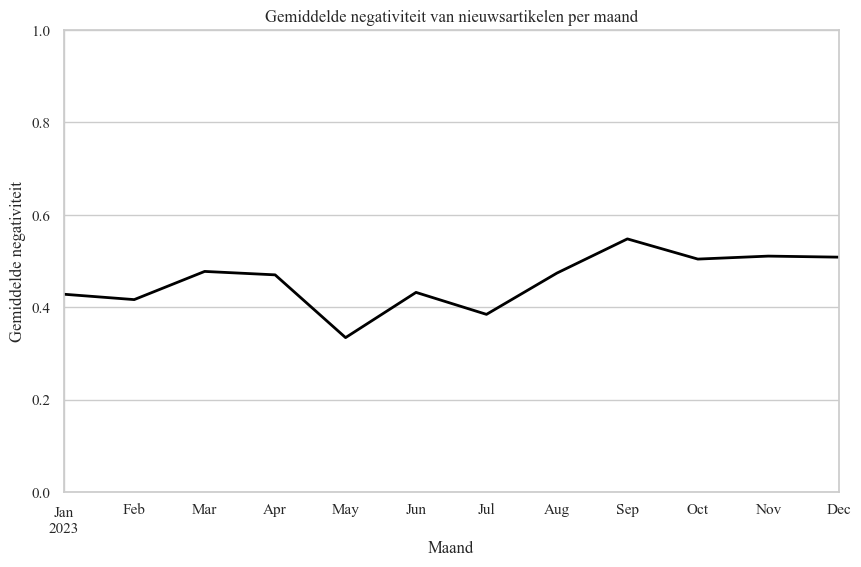

In [114]:
get_group_visuals("prop_negative", ylabel = "Gemiddelde negativiteit",
                  title="Gemiddelde negativiteit van nieuwsartikelen per maand", data=df_month, zero=False)

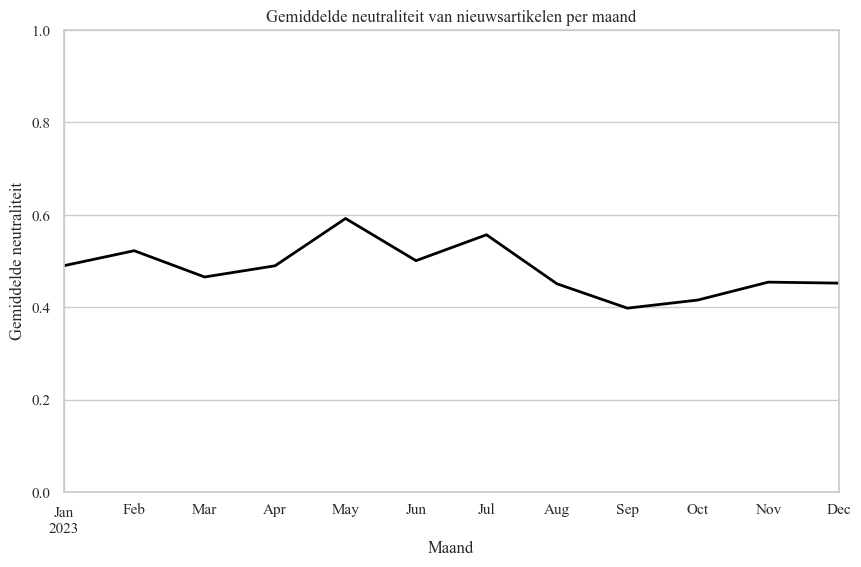

In [117]:
get_group_visuals("prop_neutral", ylabel = "Gemiddelde neutraliteit",
                  title="Gemiddelde neutraliteit van nieuwsartikelen per maand", data=df_month, zero=False)

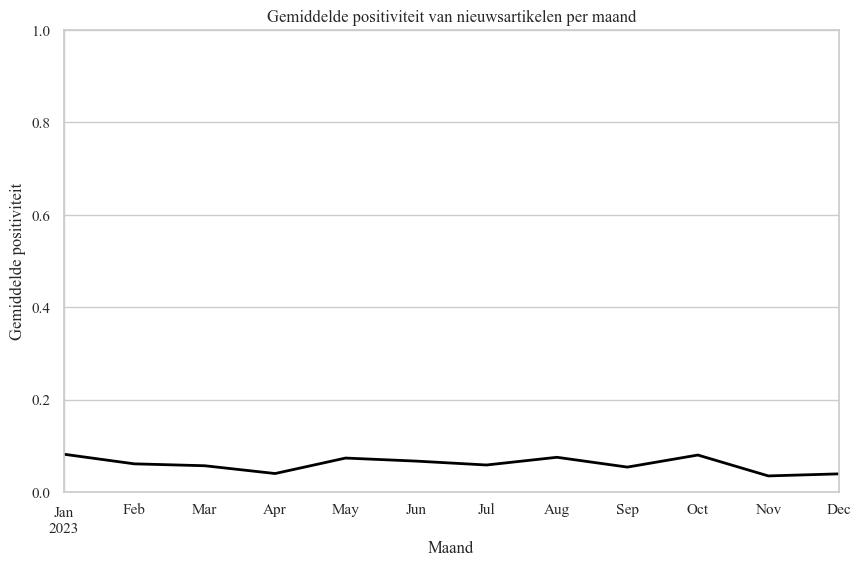

In [120]:
get_group_visuals("prop_positive", ylabel = "Gemiddelde positiviteit",
                  title="Gemiddelde positiviteit van nieuwsartikelen per maand", data=df_month, zero=False)

## Topics

In [129]:
df2.columns

Index(['section', 'title', 'outlet', 'date', 'body', 'byline', 'channel',
       'database', 'text', 'title_hits', 'body_hits', 'police_sentences',
       'is_domestic', 'domestic_prediction', 'wave', 'four_weeks', 'two_weeks',
       'outlet_type', 'en_police_sentences', 'en_police_presence',
       'police_sentences_sentiment', 'topic_bert', 'merged_topics',
       'mean_negative', 'mean_neutral', 'mean_positive', 'mean_sentiment',
       'mean_impact_size', 'max_sentiment_codes', 'prop_negative',
       'prop_neutral', 'prop_positive', 'non_neutral', 'diff_sentiment',
       'abs_sentiment', 'month'],
      dtype='object')

In [130]:
df2["text"] = df2.police_sentences.progress_apply(lambda x: " ".join(x))

100%|██████████████████████████████████████████████████████████████████████████| 1304/1304 [00:00<00:00, 652280.55it/s]


In [131]:
# Deze code maakt een nieuwe kolom.
# In deze kolom wordt de tekst in de 'text' kolom opgeschoond.
# Stopwoorden en cijfers worden verwijderd, en alleen de belangrijkste woorden blijven over.
# De woorden worden ook in hun basisvorm gezet (bijvoorbeeld 'loopt' wordt 'loop').
# Daarnaast worden bepaalde woorden die we niet willen meenemen, zoals 'police' en 'onderzoek', uit de tekst gefilterd.

dutch_stopwords = stopwords.words("dutch")

nlp = spacy.load("nl_core_news_sm")

def extract_nouns(text):
    doc = nlp(text)
    return ' '.join([token.text for token in doc if token.pos_ in ["NOUN"]])

def get_clean_text(x, exclude=None):
    x = str(x)
    x = re.sub(r"\W+", " ", x)
    x = ' '.join([word for word in x.split() if not word.isdigit()])
    x = ' '.join([word for word in x.split() if word not in dutch_stopwords])
    x = extract_nouns(x)
    x = " ".join([token.lemma_ for token in nlp(x)])
    x = x.lower()
    if exclude:
        x = re.sub(exclude, " ", x)
    x = x.strip()
    return x

exclude = r"police|onderzoek|mensen|mens|man|jaar"

df2["clean_text"] = df2.text.progress_apply(lambda x: get_clean_text(x, exclude=exclude))

100%|██████████████████████████████████████████████████████████████████████████████| 1304/1304 [00:14<00:00, 87.93it/s]


In [132]:
# Specifieke onderwerpen worden hernoemd naar bredere of meer generieke termen.
# Bijvoorbeeld, het onderwerp 'Vuurwapen geweld' wordt veranderd naar 'Vuurwapens', en 'Seksueel misbruik' naar 'Misbruik'.
# Het doel is om de onderwerpen te groeperen en te standaardiseren voor verdere analyse.

df2["merged_topics"] = df2.merged_topics.progress_apply(lambda x: "Vuurwapens" if x == "Vuurwapen geweld" else x)
df2["merged_topics"] = df2.merged_topics.progress_apply(lambda x: "Vuurwapens" if x == "16" else x)
df2["merged_topics"] = df2.merged_topics.progress_apply(lambda x: "Misbruik" if x == "Seksueel misbruik" else x)
df2["merged_topics"] = df2.merged_topics.progress_apply(lambda x: "Femicide" if x == "Jongeren" else x)
df2["merged_topics"] = df2.merged_topics.progress_apply(lambda x: "Femicide" if x == "3_" else x)
df2["merged_topics"] = df2.merged_topics.progress_apply(lambda x: "Overig" if x == "17" else x)
df2["merged_topics"] = df2.merged_topics.progress_apply(lambda x: "Organisatie" if x == "4_" else x)

100%|█████████████████████████████████████████████████████████████████████████| 1304/1304 [00:00<00:00, 1303783.65it/s]


In [133]:
# De code berekent het gemiddelde sentiment per onderwerp (topic).
# Vervolgens wordt het sentiment genormaliseerd, zodat de waarden tussen 0 en 1 vallen.
# Daarna wordt het sentiment omgezet naar een kleur, waarbij negatieve sentimenten een donkerdere rode kleur krijgen.

topic_sent = df2.groupby("merged_topics").diff_sentiment.mean().reset_index()
scaler = MinMaxScaler()
topic_sent['norm_sentiment'] = scaler.fit_transform(topic_sent[['diff_sentiment']])

def sentiment_to_red(sentiment):
    red_intensity = min(max(-sentiment * 255, 0), 255)
    return f"rgb({int(red_intensity)}, 0, 0)"

topic_sent["color"] = topic_sent["diff_sentiment"].apply(sentiment_to_red)

In [144]:
# De code maakt een WordCloud voor elk onderwerp (behalve "Overig").
# Het sentiment van elk onderwerp wordt omgezet naar een kleur, variërend van rood naar geel afhankelijk van het sentiment.
# Vervolgens wordt de tekst voor elk onderwerp verzameld, en een WordCloud wordt gegenereerd met de bijbehorende kleur.
# De WordClouds worden opgeslagen in een lijst voor later gebruik.

def sentiment_to_red_yellow(sentiment):
    red = 255
    green = int((1 + sentiment) * 255) 
    blue = 0
    return f"rgb({red}, {green}, {blue})"

topic_sent["color"] = topic_sent["diff_sentiment"].apply(sentiment_to_red_yellow)

wcs = []

for t in tqdm(df2.merged_topics.unique()):
    if t == "Overig":
        continue
    else:
        color_code = topic_sent[topic_sent.merged_topics == t].color.values[0]
        r, g, b = [int(x) for x in color_code[4:-1].split(",")]
        
        text = " ".join(df2[df2.merged_topics == t].clean_text.values)
        
        wc = WordCloud(
            background_color='white', 
            width=1200, 
            height=750,
            font_path="C:\\Windows\\Fonts\\times.ttf",
            color_func=lambda *args, **kwargs: f'rgb({r}, {g}, {b})').generate(text)
        
        wcs.append(wc)

100%|██████████████████████████████████████████████████████████████████████████████████| 13/13 [00:09<00:00,  1.40it/s]


C:\Users\dubel\AppData\Local\Temp\ipykernel_17524\552732955.py:19: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])


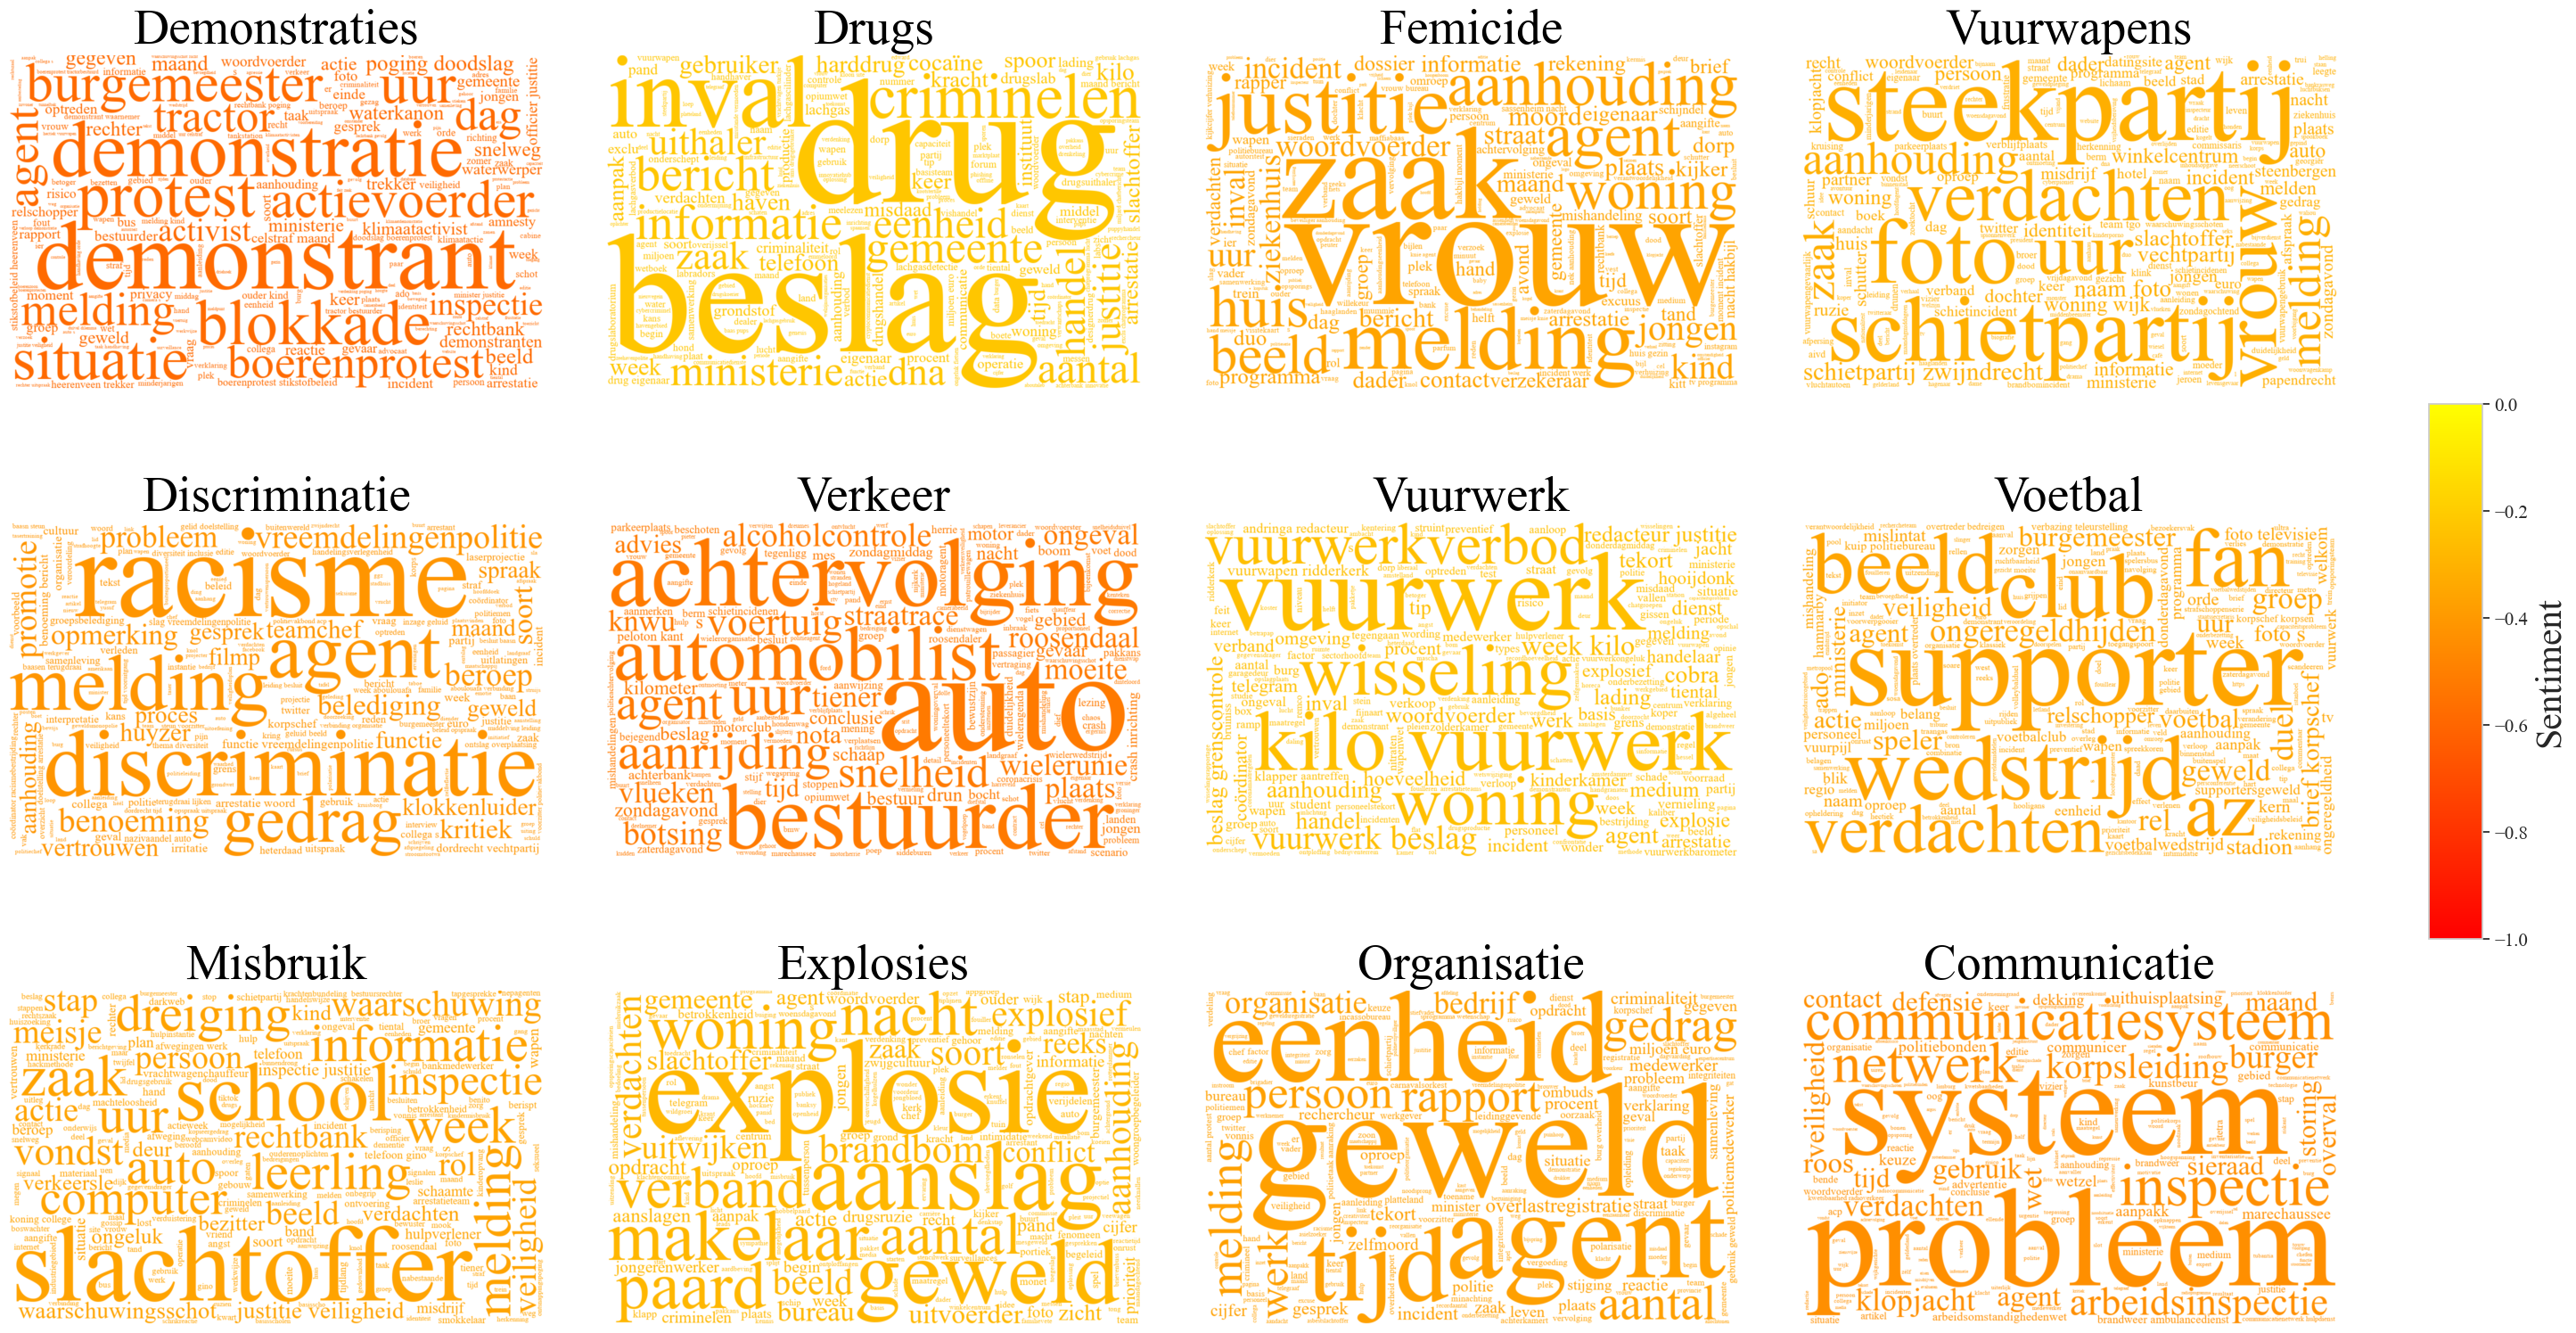

In [145]:
# De code maakt een raster van WordClouds voor verschillende onderwerpen, waarbij elk onderwerp een specifieke kleur krijgt op basis van het sentiment (rood voor negatief, geel voor neutraal).
# Elke WordCloud wordt weergegeven in een subplot met de bijbehorende titel van het onderwerp.
# Aan de rechterkant wordt een kleurenschaal (colorbar) toegevoegd om het sentiment visueel weer te geven, van rood (negatief) naar geel (neutraal).

topics = df2[df2.merged_topics != "Overig"].merged_topics.unique()

cmap = mpl.colors.LinearSegmentedColormap.from_list("RedYellow", ["red", "yellow"])
norm = mpl.colors.Normalize(vmin=-1, vmax=0) 

fig, axs = plt.subplots(3, 4, figsize=(30, 15))
for ax, wc, topic in zip(axs.flatten(), wcs, topics):
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(topic.capitalize(), fontsize=40, fontname="Times New Roman", color="black", pad=10)

cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4]) 
cb = mpl.colorbar.ColorbarBase(cbar_ax, cmap=cmap, norm=norm, orientation='vertical')
cb.set_label("Sentiment", fontsize=30, fontname="Times New Roman")
cb.ax.tick_params(labelsize=15)
for tick in cb.ax.get_yticklabels():
    tick.set_fontname("Times New Roman")

plt.tight_layout(rect=[0, 0, 0.9, 1]) 
plt.subplots_adjust(hspace=0.4)
plt.savefig('figures/Woorden en sentiment per topic.png', dpi=600, bbox_inches='tight', pad_inches=0.1)

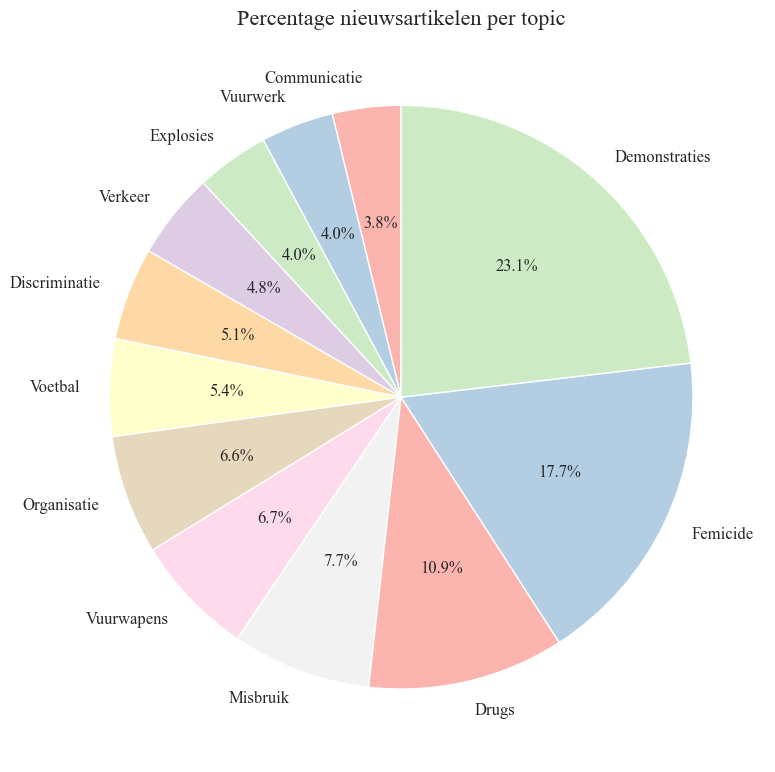

In [142]:
# De code maakt een taartdiagram die het percentage nieuwsartikelen per onderwerp weergeeft, exclusief het onderwerp "Overig".
# De onderwerpen worden gesorteerd op basis van hun frequentie, van het minste naar het meeste aantal artikelen.
# De taartdiagram toont de verdeling van de artikelen per onderwerp in percentages.

topic_counts = df2[df2.merged_topics != "Overig"].merged_topics.value_counts()

topic_counts_sorted = topic_counts.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    topic_counts_sorted.values, 
    labels=topic_counts_sorted.index, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=plt.cm.Pastel1.colors, 
    textprops={'fontsize': 12, 'fontname': 'Times New Roman'} 
)

ax.set_title("Percentage nieuwsartikelen per topic", fontsize=16, fontname="Times New Roman")
plt.tight_layout()

plt.savefig('figures/Percentage nieuwsartikelen per topic.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

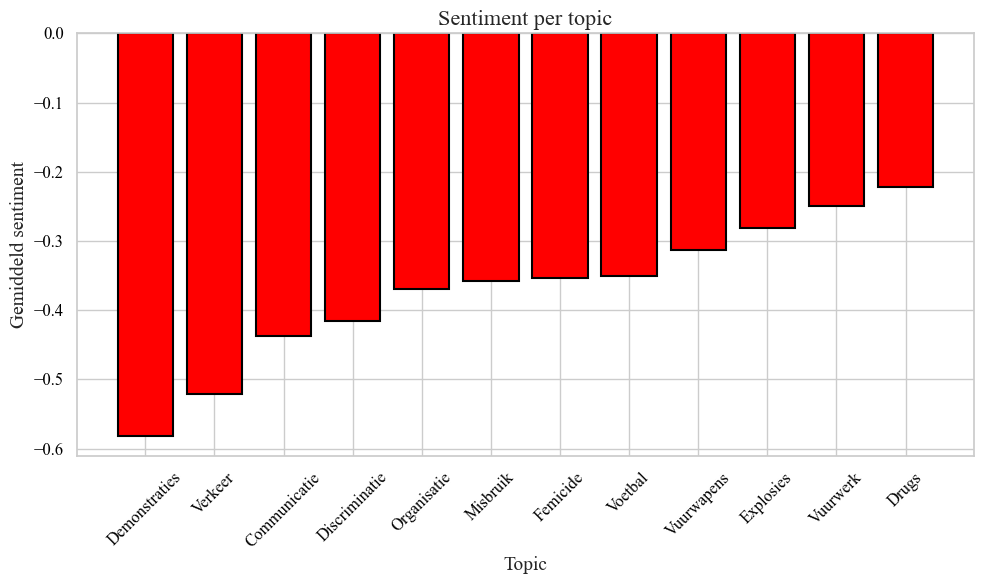

In [143]:
# De code maakt een staafgrafiek die het gemiddelde sentiment per onderwerp toont, exclusief het onderwerp "Overig".
# De onderwerpen worden gesorteerd van het meest negatieve sentiment naar het minst negatieve.

topic_sentiment = df2[df2.merged_topics != "Overig"].groupby("merged_topics").diff_sentiment.mean()
topic_sentiment_sorted = topic_sentiment.sort_values(ascending=True)  # Ascending to get most negative on the left

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    topic_sentiment_sorted.index, 
    topic_sentiment_sorted.values, 
    color='red', 
    edgecolor='black', 
    linewidth=1.5)

font_properties = {'fontsize': 14, 'fontname': 'Times New Roman'}

ax.set_title("Sentiment per topic", fontsize=16, fontname="Times New Roman")
ax.set_xlabel("Topic", **font_properties)
ax.set_ylabel("Gemiddeld sentiment", **font_properties)

ax.tick_params(axis='x', rotation=45, labelsize=12, labelcolor="black")
ax.tick_params(axis='y', labelsize=12, labelcolor="black")
for tick in ax.get_xticklabels():
    tick.set_fontname("Times New Roman")
for tick in ax.get_yticklabels():
    tick.set_fontname("Times New Roman")

plt.tight_layout()
plt.savefig('figures/Sentiment per topic.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()

In [160]:
# Deze code maakt een overzicht van het aantal artikelen en het gemiddelde van verschillende kenmerken per maand en outlet voor het onderwerp "Demonstraties".
# Eerst worden de gegevens over de maand en het type outlet gegroepeerd, waarna de gemiddelde waarden van bepaalde kenmerken per groep worden berekend.

df_month_demo = df2[df2.merged_topics == "Demonstraties"].groupby(["month", 'outlet_type', 'outlet'])[features].mean().reset_index()
df_month_demo["month_codes"] = pd.Categorical(df_month_demo['month']).codes
df_attention_demo = df2[df2.merged_topics == "Demonstraties"].groupby(["month", 'outlet_type', 'outlet']).size().reset_index().rename(columns={0:"attention"})
df_attention_demo["month_codes"] = pd.Categorical(df_attention_demo['month']).codes
df_month_demo = df_month_demo.merge(df_attention_demo.drop(columns=['month']), on=["month_codes", 'outlet_type', 'outlet'])

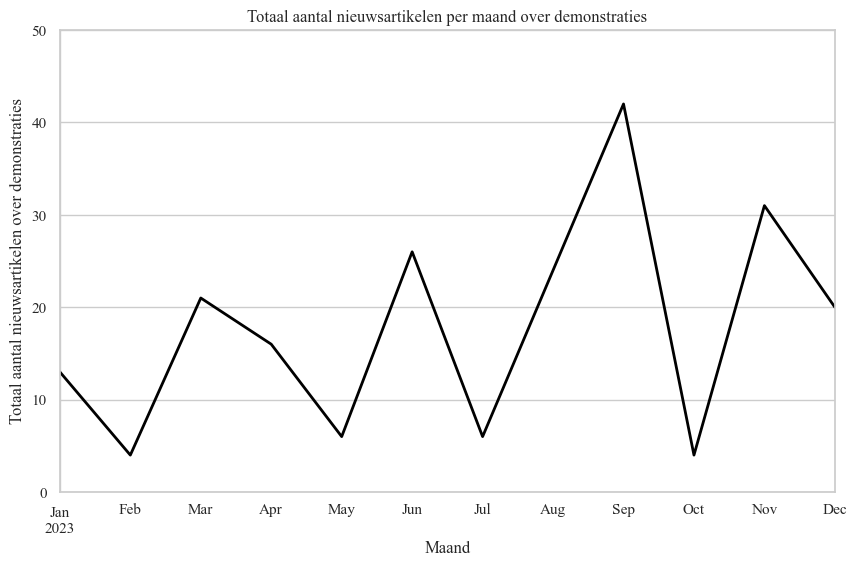

In [166]:
get_group_visuals("attention", ylabel = "Totaal aantal nieuwsartikelen over demonstraties",
                  title="Totaal aantal nieuwsartikelen per maand over demonstraties", data=df_month_demo, zero=False, ymax=50)

## Actoren

In [168]:
# De code gebruikt een taalmodel om automatisch namen van mensen en organisaties uit de tekst te halen.
# Het resultaat is een nieuwe kolom in de data waarin voor elke tekst de gevonden namen van mensen en organisaties staan.

nlp = spacy.load("nl_core_news_lg")

def get_actors(x, nlp=nlp):
    doc = nlp(x)
    actors = [ent.text for ent in doc.ents if ent.label_ in ["PERSON", "ORG"] and "POLICE" not in ent.text.upper()]
    return list(set(actors))

df2["actors"] = df2.text.progress_apply(lambda x: get_actors(x))

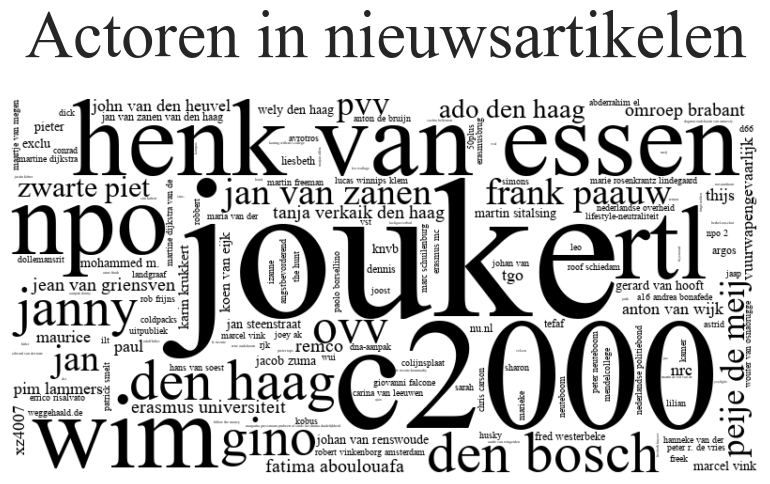

In [171]:
# De code maakt een WordCloud van de namen die uit de teksten zijn gehaald.
# Het verwijdert specifieke woorden om de lijst te filteren.
# Daarna wordt een grafiek gegenereerd die de frequentie van de genoemde actoren visueel weergeeft.

actors = list(chain(*df2.actors.to_list()))

remove_words = ["tips", "dateline", "bij"]

filtered_actors = [actor for actor in actors if actor.lower() not in map(str.lower, remove_words)]

actor_counts = Counter(filtered_actors)

wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    color_func=lambda *args, **kwargs: 'black',  
    contour_color='black',  
    font_path="C:\\Windows\\Fonts\\times.ttf",
    contour_width=1).generate_from_frequencies(actor_counts)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")  

plt.title("Actoren in nieuwsartikelen", fontsize=48, fontname="Times New Roman", pad=30)

plt.subplots_adjust(top=0.85)

plt.tight_layout()
plt.savefig('figures/Actoren in nieuwsartikelen.png', dpi=600, bbox_inches='tight', pad_inches=0.1)
plt.show()